In [3]:
# Sprawdzamy nazwy kolumn i czy są braki w danych
df.info()

# Sprawdzamy podstawowe statystyki (średnia sprzedaż, max, min)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer ID     51290 non-null  str    
 4   Customer Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   è®°å½æ°       51290 non-null  int64  
 8   Order Date      51290 non-null  str    
 9   Order ID        51290 non-null  str    
 10  Order Priority  51290 non-null  str    
 11  Product ID      51290 non-null  str    
 12  Product Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null  int64  
 1

,Discount,è®°å½æ°,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Próbujemy wczytać plik. 
# Global Superstore często używa kodowania 'latin-1' lub 'ISO-8859-1'
# Jeśli to plik tekstowy, sprawdzimy separator (przecinek lub tabulator)
try:
    df = pd.read_csv('Global Superstore.txt', sep='\t', encoding='ISO-8859-1')
except:
    df = pd.read_csv('Global Superstore.txt', sep=',', encoding='ISO-8859-1')

# Wyświetlamy pierwsze wiersze, żeby zobaczyć czy dane wyglądają dobrze
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,è®°å½æ°,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
# 1. Konwersja daty na format czasowy
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 2. Wyciągamy Rok i Miesiąc do osobnych kolumn (ułatwi analizę trendów)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

# 3. Sprawdźmy, czy mamy jakieś puste wartości (NaN)
print("Brakujące dane:")
print(df.isnull().sum())

# 4. Podgląd oczyszczonych danych
df[['Order Date', 'Year', 'Month', 'Sales', 'Profit']].head()

Brakujące dane:
Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
è®°å½æ°         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
Month             0
dtype: int64


,Order Date,Year,Month,Sales,Profit
0,2011-01-07,2011,2011-01,19,9.3312
1,2011-01-21,2011,2011-01,19,9.2928
2,2011-08-05,2011,2011-08,21,9.8418
3,2011-08-05,2011,2011-08,111,53.2608
4,2011-09-29,2011,2011-09,6,3.1104


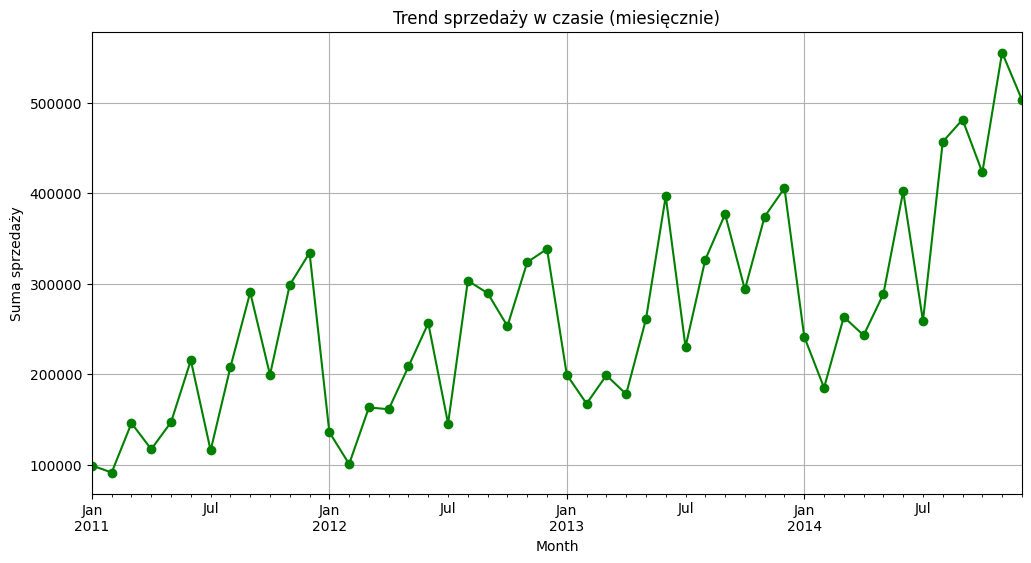

In [5]:
# Grupowanie sprzedaży po miesiącach
monthly_sales = df.groupby('Month')['Sales'].sum()

# Prosty wykres trendu
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Trend sprzedaży w czasie (miesięcznie)')
plt.ylabel('Suma sprzedaży')
plt.grid(True)
plt.show()

C:\Users\Rafał\AppData\Local\Temp\ipykernel_22996\495349828.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_analysis.values, y=category_analysis.index, palette='viridis')


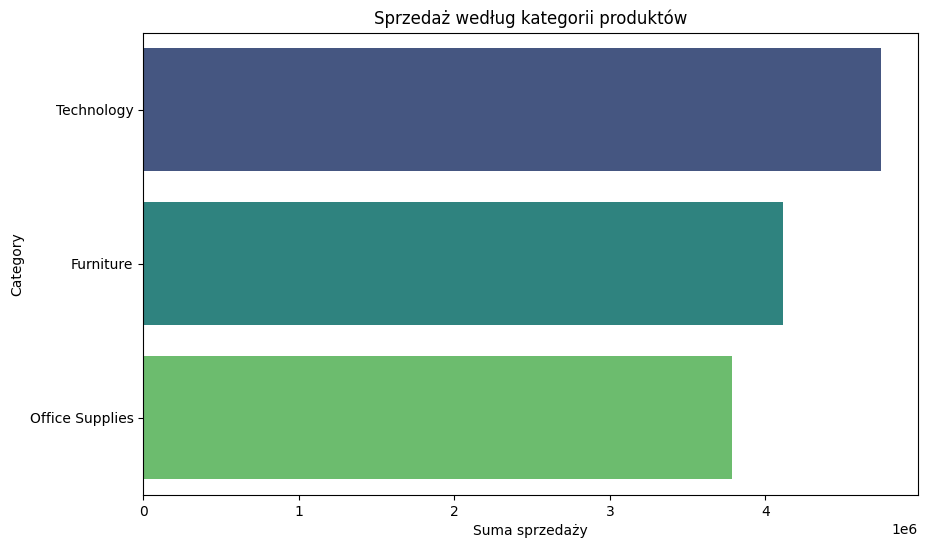

Średnia wartość zamówienia (AOV) wynosi: 505.01


In [6]:
# 1. Agregacja sprzedaży według kategorii
category_analysis = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# 2. Wizualizacja Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=category_analysis.values, y=category_analysis.index, palette='viridis')
plt.title('Sprzedaż według kategorii produktów')
plt.xlabel('Suma sprzedaży')
plt.show()

# 3. Średnia Wartość Zamówienia (AOV)
# Obliczamy sumę sprzedaży / liczbę unikalnych Order ID
aov = df['Sales'].sum() / df['Order ID'].nunique()
print(f"Średnia wartość zamówienia (AOV) wynosi: {aov:.2f}")

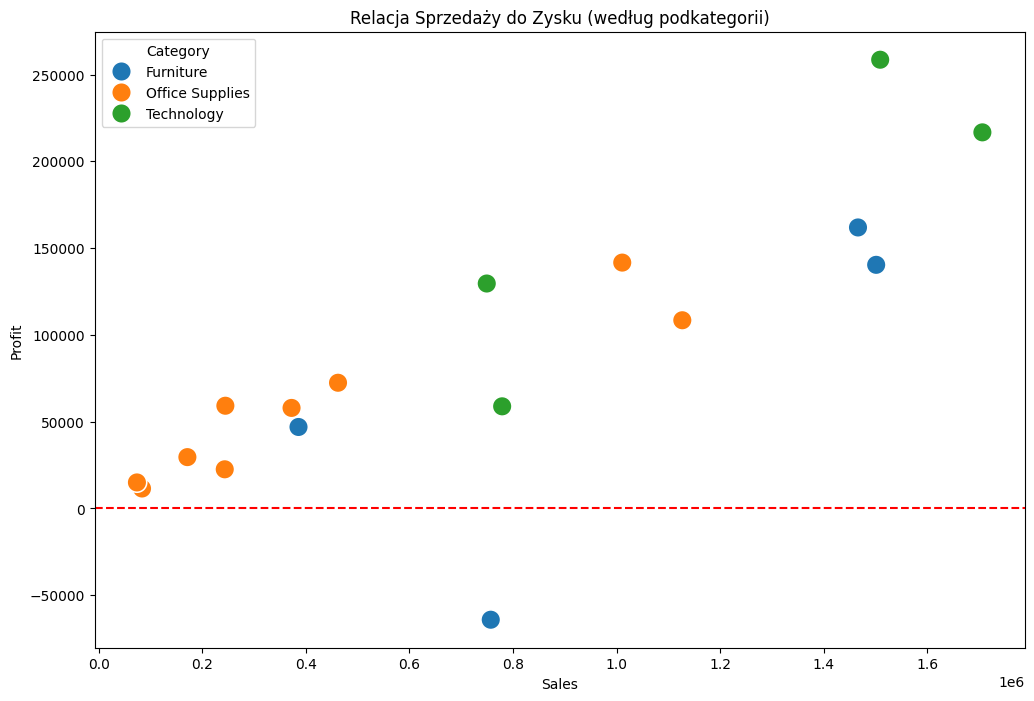

Podkategorie generujące największe straty:


,Category,Sub-Category,Sales,Profit
3,Furniture,Tables,757034,-64083.3887
8,Office Supplies,Fasteners,83254,11525.4241
9,Office Supplies,Labels,73433,15010.5120
12,Office Supplies,Supplies,243090,22583.2631
7,Office Supplies,Envelopes,170926,29601.1163


In [7]:
# 1. Sprawdzenie zysku według kategorii i podkategorii
profit_analysis = df.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum().reset_index()

# 2. Wykres punktowy: Sprzedaż vs Zysk
plt.figure(figsize=(12, 8))
sns.scatterplot(data=profit_analysis, x='Sales', y='Profit', hue='Category', s=200)

# Dodajemy linię zero, aby widzieć co jest pod kreską
plt.axhline(0, color='red', linestyle='--')
plt.title('Relacja Sprzedaży do Zysku (według podkategorii)')
plt.show()

# 3. TOP 5 najbardziej stratnych podkategorii
print("Podkategorie generujące największe straty:")
display(profit_analysis.sort_values(by='Profit').head(5))

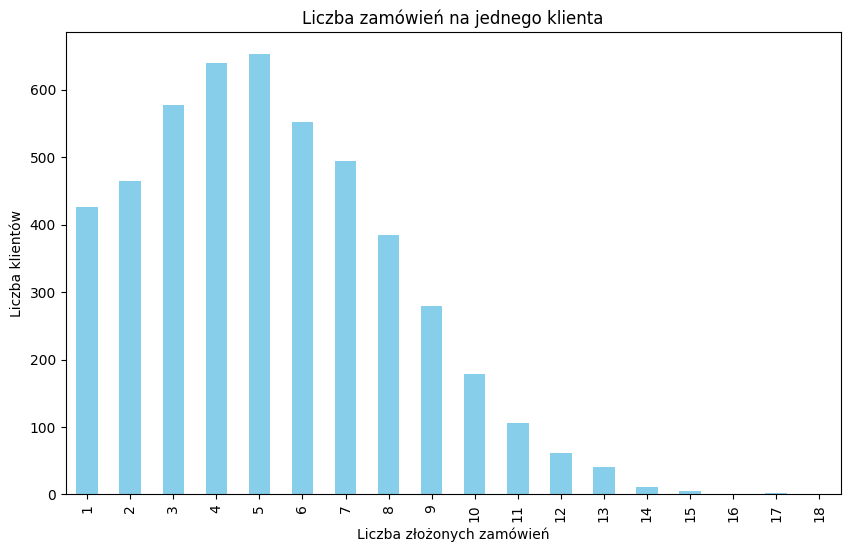

Wskaźnik powracających klientów: 91.26%


In [8]:
# 1. Liczymy ile razy każdy klient zrobił zakupy
customer_loyalty = df.groupby('Customer ID')['Order ID'].nunique().value_counts().sort_index()

# 2. Wykres lojalności
plt.figure(figsize=(10, 6))
customer_loyalty.plot(kind='bar', color='skyblue')
plt.title('Liczba zamówień na jednego klienta')
plt.xlabel('Liczba złożonych zamówień')
plt.ylabel('Liczba klientów')
plt.show()

# 3. Procentowy udział powracających klientów
repeat_customers = df.groupby('Customer ID')['Order ID'].nunique()
repeat_rate = (repeat_customers > 1).sum() / len(repeat_customers) * 100
print(f"Wskaźnik powracających klientów: {repeat_rate:.2f}%")

# Raport: Analiza Sprzedaży Global Superstore

## Główne wnioski:
1. **Silna Sezonowość:** Sprzedaż gwałtownie rośnie w Q4 (listopad-grudzień). Należy zwiększyć stany magazynowe już we wrześniu.
2. **Kryzys w podkategorii Stoły:** Mimo wysokich obrotów, stoły generują największe straty netto. 
3. **Złota Retencja:** Ponad 91% klientów to klienci powracający. Biznes opiera się na lojalności, nie na nowym ruchu.

## Rekomendacje:
- **Zoptymalizuj logistykę stołów:** Należy rozważyć podniesienie cen dostawy dla gabarytów lub rezygnację z darmowej wysyłki w tej kategorii.
- **Cross-selling:** Wykorzystaj wysoką retencję. Skoro klienci wracają, promuj wśród nich wysokomarżowe akcesoria (Office Supplies) zamiast niskomarżowych mebli.
- **Strategia Rabatoowa:** Sprawdź, czy straty w Furniture nie wynikają ze zbyt dużych zniżek (kolumna Discount) i wprowadź limity rabatów.

C:\Users\Rafał\AppData\Local\Temp\ipykernel_22996\3377437991.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_analysis, x='Margin %', y='Sub-Category', palette='RdYlGn')


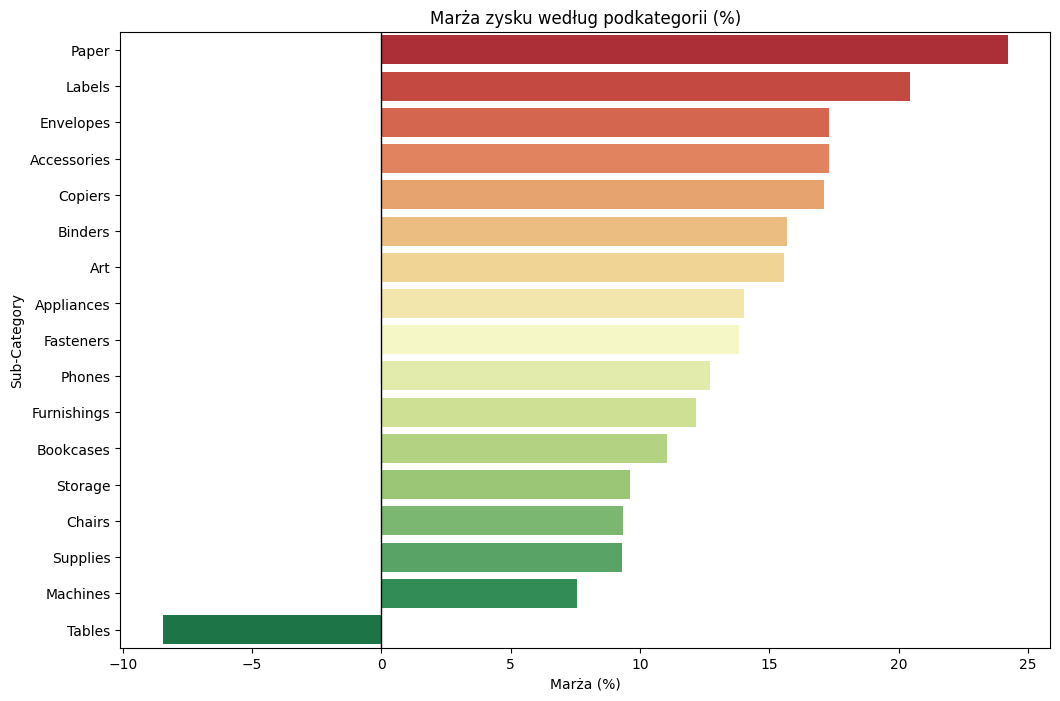

TOP 5 najbardziej marżowych produktów:


,Sub-Category,Sales,Profit,Margin %
12,Paper,244307,59207.68270,24.234951
10,Labels,73433,15010.51200,20.441099
7,Envelopes,170926,29601.11630,17.318089
0,Accessories,749307,129626.30620,17.299492
6,Copiers,1509439,258567.54818,17.130043


In [9]:
# 1. Agregacja danych dla wszystkich podkategorii
sub_analysis = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# 2. Obliczanie Marży Zysku (Profit Margin) w %
sub_analysis['Margin %'] = (sub_analysis['Profit'] / sub_analysis['Sales']) * 100

# 3. Sortowanie według marży, żeby zobaczyć co jest najbardziej dochodowe
sub_analysis = sub_analysis.sort_values(by='Margin %', ascending=False)

# 4. Wizualizacja Marży
plt.figure(figsize=(12, 8))
sns.barplot(data=sub_analysis, x='Margin %', y='Sub-Category', palette='RdYlGn')
plt.axvline(0, color='black', lw=1)
plt.title('Marża zysku według podkategorii (%)')
plt.xlabel('Marża (%)')
plt.show()

print("TOP 5 najbardziej marżowych produktów:")
display(sub_analysis.head(5))

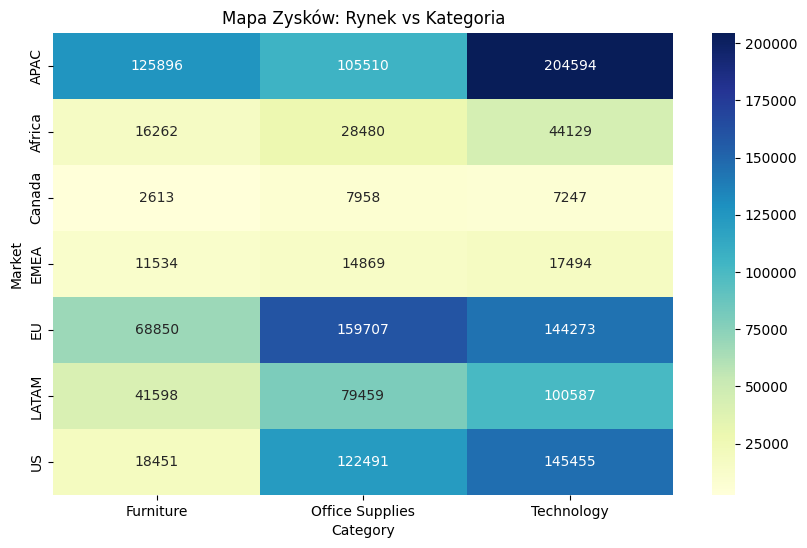

In [10]:
# Grupowanie zysku według rynku (Market) i kategorii
market_profit = df.pivot_table(index='Market', columns='Category', values='Profit', aggfunc='sum')

# Heatmapa - wizualizacja, gdzie zarabiamy najwięcej
plt.figure(figsize=(10, 6))
sns.heatmap(market_profit, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Mapa Zysków: Rynek vs Kategoria')
plt.show()